In [1]:
import pandas as pd




In [5]:
df = pd.read_csv("Telecom_cleaned.csv")


In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,0,-1.277445,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1,Electronic check,-1.160323,-0.994194,0
1,5575-GNVDE,Male,0,0,0,0.066327,1,No,DSL,Yes,...,Yes,No,No,No,One year,0,Mailed check,-0.259629,-0.173740,0
2,3668-QPYBK,Male,0,0,0,-1.236724,1,No,DSL,Yes,...,No,No,No,No,Month-to-month,1,Mailed check,-0.362660,-0.959649,1
3,7795-CFOCW,Male,0,0,0,0.514251,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,0,Bank transfer (automatic),-0.746535,-0.195248,0
4,9237-HQITU,Female,0,0,0,-1.236724,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Electronic check,0.197365,-0.940457,1


In [9]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   float64
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   int64  


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7.043000e+03,7043.000000,7043.000000,7.043000e+03,7.032000e+03,7043.000000
mean,0.162147,0.483033,0.299588,-1.916841e-17,0.903166,0.592219,-6.204512e-17,8.790844e-17,0.265370
std,0.368612,0.499748,0.458110,1.000071e+00,0.295752,0.491457,1.000071e+00,1.000071e+00,0.441561
min,0.000000,0.000000,0.000000,-1.318165e+00,0.000000,0.000000,-1.545860e+00,-9.990692e-01,0.000000
25%,0.000000,0.000000,0.000000,-9.516817e-01,1.000000,0.000000,-9.725399e-01,-8.302488e-01,0.000000
50%,0.000000,0.000000,0.000000,-1.372744e-01,1.000000,1.000000,1.857327e-01,-3.908151e-01,0.000000
75%,0.000000,1.000000,1.000000,9.214551e-01,1.000000,1.000000,8.338335e-01,6.668271e-01,1.000000
max,1.000000,1.000000,1.000000,1.613701e+00,1.000000,1.000000,1.794352e+00,2.824261e+00,1.000000


In [11]:
df = df.drop("customerID", axis=1)

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [15]:
#Churn Rate=Clients perdus/Clients totaux

df['Churn'].mean()

0.2653698707936959

In [17]:
df['MonthlyCharges'].mean()

-6.204512033117444e-17

In [19]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [23]:
y_pred = model.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

confusion_matrix(y_test, y_pred)

Accuracy : 0.7927608232789212


array([[941,  95],
       [197, 176]], dtype=int64)

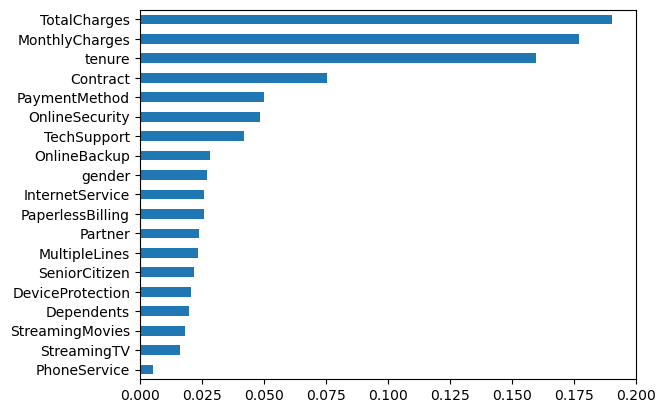

In [27]:
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.show()

<Axes: xlabel='Churn', ylabel='count'>

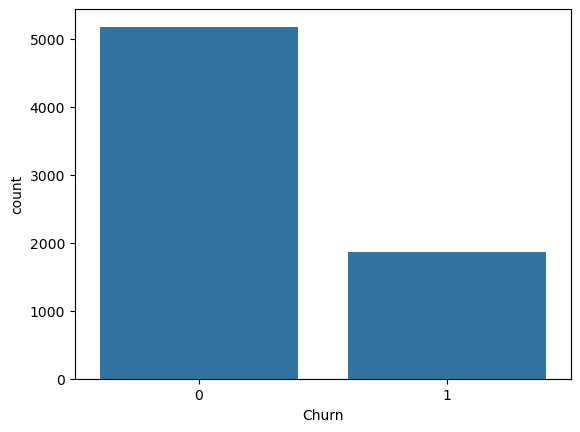

In [29]:
import seaborn as sns

sns.countplot(x='Churn', data=df)